In [ ]:
import marimo as mo
import pandas as pd
# import numpy as np
import random

# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler  # , LabelEncoder
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [ ]:
titles = [f"Banda {number}" for number in range(0, 60)]
titles.append("Oggetto")


df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data",
    names=titles,
)


# Roccia = 0, Mina = 1

df["Oggetto"] = df["Oggetto"].replace({"R": 0, "M": 1})

x = df.iloc[:, :-1]
y = df["Oggetto"]

df.head()

C:\Users\geome\AppData\Local\Temp\marimo_31600\__marimo__cell_Hbol_.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Oggetto"] = df["Oggetto"].replace({"R": 0, "M": 1})


<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"Banda 0\":0.02,\"Banda 1\":0.0371,\"Banda 2\":0.0428,\"Banda 3\":0.0207,\"Banda 4\":0.0954,\"Banda 5\":0.0986,\"Banda 6\":0.1539,\"Banda 7\":0.1601,\"Banda 8\":0.3109,\"Banda 9\":0.2111,\"Banda 10\":0.1609,\"Banda 11\":0.1582,\"Banda 12\":0.2238,\"Banda 13\":0.0645,\"Banda 14\":0.066,\"Banda 15\":0.2273,\"Banda 16\":0.31,\"Banda 17\":0.2999,\"Banda 18\":0.5078,\"Banda 19\":0.4797,\"Banda 20\":0.5783,\"Banda 21\":0.5071,\"Banda 22\":0.4328,\"Banda 23\":0.555,\"Banda 24\":0.6711,\"Banda 25\":0.6415,\"Banda 26\":0.7104,\"Banda 27\":0.808,\"Banda 28\":0.6791,\"Banda 29\":0.3857,\"Banda 30\":0.1307,\"Banda 31\":0.2604,\"Banda 32\":0.5121,\"Banda 33\":0.7547,\"Banda 34\":0.8537,\"Banda 35\":0.8507,\"Banda 36\":0.6692,\"Banda 37\":0.6097,\"Banda 38\":0.4943,\"Banda 39\":0.2744,\"Banda 40\":0.051,\"Banda 41\":0.2834,\"Banda 42\":0.2825,\"Banda 43\":0.4256,\"Banda 44\":0.2641,\"Banda 45\":0.1386,\"Banda 46\":0.1051,\"Banda 47\":0.1343,\"Banda 48\":0.0383,\"Banda 49\":0.0324},{\"Banda 0\":0.0453,\"Banda 1\":0.0523,\"Banda 2\":0.0843,\"Banda 3\":0.0689,\"Banda 4\":0.1183,\"Banda 5\":0.2583,\"Banda 6\":0.2156,\"Banda 7\":0.3481,\"Banda 8\":0.3337,\"Banda 9\":0.2872,\"Banda 10\":0.4918,\"Banda 11\":0.6552,\"Banda 12\":0.6919,\"Banda 13\":0.7797,\"Banda 14\":0.7464,\"Banda 15\":0.9444,\"Banda 16\":1.0,\"Banda 17\":0.8874,\"Banda 18\":0.8024,\"Banda 19\":0.7818,\"Banda 20\":0.5212,\"Banda 21\":0.4052,\"Banda 22\":0.3957,\"Banda 23\":0.3914,\"Banda 24\":0.325,\"Banda 25\":0.32,\"Banda 26\":0.3271,\"Banda 27\":0.2767,\"Banda 28\":0.4423,\"Banda 29\":0.2028,\"Banda 30\":0.3788,\"Banda 31\":0.2947,\"Banda 32\":0.1984,\"Banda 33\":0.2341,\"Banda 34\":0.1306,\"Banda 35\":0.4182,\"Banda 36\":0.3835,\"Banda 37\":0.1057,\"Banda 38\":0.184,\"Banda 39\":0.197,\"Banda 40\":0.1674,\"Banda 41\":0.0583,\"Banda 42\":0.1401,\"Banda 43\":0.1628,\"Banda 44\":0.0621,\"Banda 45\":0.0203,\"Banda 46\":0.053,\"Banda 47\":0.0742,\"Banda 48\":0.0409,\"Banda 49\":0.0061},{\"Banda 0\":0.0262,\"Banda 1\":0.0582,\"Banda 2\":0.1099,\"Banda 3\":0.1083,\"Banda 4\":0.0974,\"Banda 5\":0.228,\"Banda 6\":0.2431,\"Banda 7\":0.3771,\"Banda 8\":0.5598,\"Banda 9\":0.6194,\"Banda 10\":0.6333,\"Banda 11\":0.706,\"Banda 12\":0.5544,\"Banda 13\":0.532,\"Banda 14\":0.6479,\"Banda 15\":0.6931,\"Banda 16\":0.6759,\"Banda 17\":0.7551,\"Banda 18\":0.8929,\"Banda 19\":0.8619,\"Banda 20\":0.7974,\"Banda 21\":0.6737,\"Banda 22\":0.4293,\"Banda 23\":0.3648,\"Banda 24\":0.5331,\"Banda 25\":0.2413,\"Banda 26\":0.507,\"Banda 27\":0.8533,\"Banda 28\":0.6036,\"Banda 29\":0.8514,\"Banda 30\":0.8512,\"Banda 31\":0.5045,\"Banda 32\":0.1862,\"Banda 33\":0.2709,\"Banda 34\":0.4232,\"Banda 35\":0.3043,\"Banda 36\":0.6116,\"Banda 37\":0.6756,\"Banda 38\":0.5375,\"Banda 39\":0.4719,\"Banda 40\":0.4647,\"Banda 41\":0.2587,\"Banda 42\":0.2129,\"Banda 43\":0.2222,\"Banda 44\":0.2111,\"Banda 45\":0.0176,\"Banda 46\":0.1348,\"Banda 47\":0.0744,\"Banda 48\":0.013,\"Banda 49\":0.0106},{\"Banda 0\":0.01,\"Banda 1\":0.0171,\"Banda 2\":0.0623,\"Banda 3\":0.0205,\"Banda 4\":0.0205,\"Banda 5\":0.0368,\"Banda 6\":0.1098,\"Banda 7\":0.1276,\"Banda 8\":0.0598,\"Banda 9\":0.1264,\"Banda 10\":0.0881,\"Banda 11\":0.1992,\"Banda 12\":0.0184,\"Banda 13\":0.2261,\"Banda 14\":0.1729,\"Banda 15\":0.2131,\"Banda 16\":0.0693,\"Banda 17\":0.2281,\"Banda 18\":0.406,\"Banda 19\":0.3973,\"Banda 20\":0.2741,\"Banda 21\":0.369,\"Banda 22\":0.5556,\"Banda 23\":0.4846,\"Banda 24\":0.314,\"Banda 25\":0.5334,\"Banda 26\":0.5256,\"Banda 27\":0.252,\"Banda 28\":0.209,\"Banda 29\":0.3559,\"Banda 30\":0.626,\"Banda 31\":0.734,\"Banda 32\":0.612,\"Banda 33\":0.3497,\"Banda 34\":0.3953,\"Banda 35\":0.3012,\"Banda 36\":0.5408,\"Banda 37\":0.8814,\"Banda 38\":0.9857,\"Banda 39\":0.9167,\"Banda 40\":0.6121,\"Banda 41\":0.5006,\"Banda 42\":0.321,\"Banda 43\":0.3202,\"Banda 44\":0.4295,\"Banda 45\":0.3654,\"Banda 46\":0.2655,\"Banda 47\":0.1576,\"Banda 48\":0.0681,\"Banda 49\":0.02

# Scaling delle feature e applicazione della LDA

In [ ]:
seed = random.randint(0, 50)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed, stratify=y
)

lda = LinearDiscriminantAnalysis()
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

# Esecuzione del modello

In [ ]:
y_pred = lda.fit(x_train, y_train).predict(
    x_test
)  # il dataset di test è come un foglio di verifica

## Metriche di performance

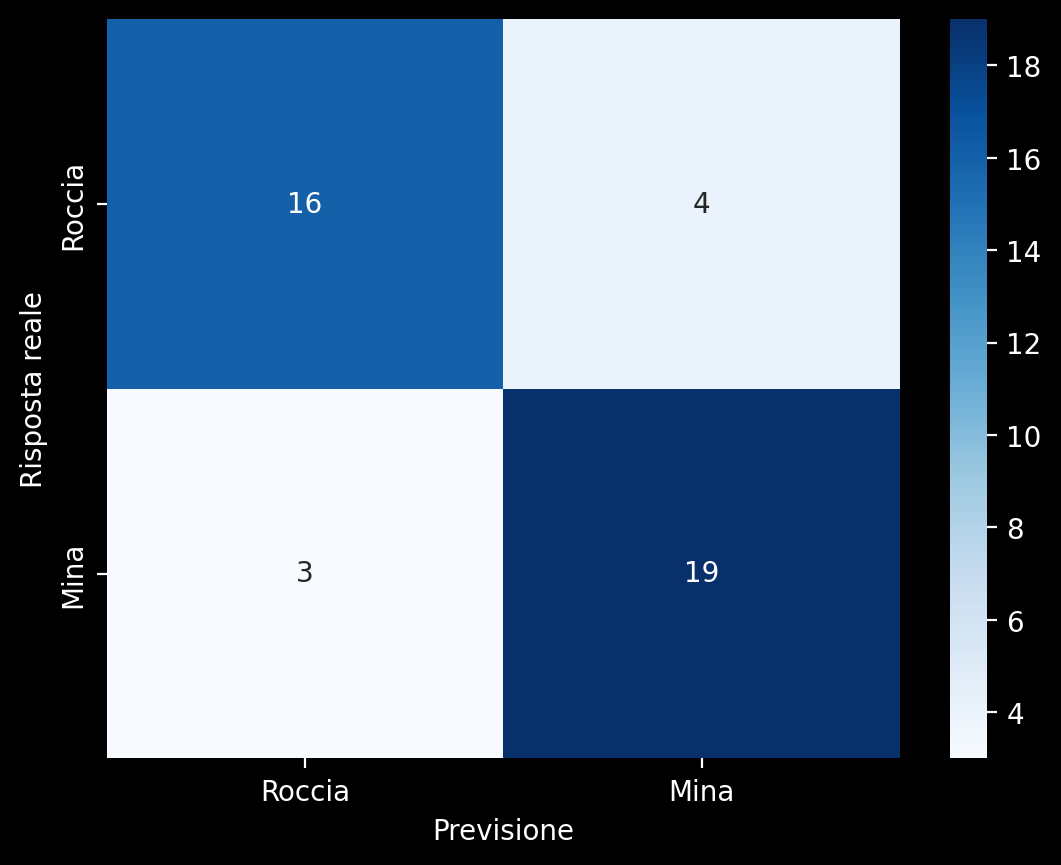

In [ ]:
from sklearn.metrics import confusion_matrix

confmat = confusion_matrix(y_test, y_pred)
labels = ["Roccia", "Mina"]

sns.heatmap(
    data=confmat,
    annot=True,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Previsione")
plt.ylabel("Risposta reale")
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Calcolo delle figure di merito
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Stampa delle figure di merito

In [ ]:
mo.md(rf"""
Il modello appena eseguito ha restituito le seguenti metriche: 
- Accuratezza: ${round(accuracy, 3) * 100}\%$
- Precisione: ${round(precision, 3) * 100}\%$
- Recall: ${round(recall, 3) * 100}\%$
- F1-score: ${round(f1, 3) * 100}\%$
""")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Il modello appena eseguito ha restituito le seguenti metriche: </span>
<ul>
<li>Accuratezza: $83.3\%$</li>
<li>Precisione: $83.39999999999999\%$</li>
<li>Recall: $83.3\%$</li>
<li>F1-score: $83.3\%$</li>
</ul></span>